In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

# Summary of fixes:

- I only use the embedding function with the symmetric matrix
- Corrected the markdown notation for $D_\alpha^{-1/2}$
- All orderings of eigenvectors use correct index notation
- The grid of epsilons for bandwidth-selection now depends on the median of the smallest value in each row of the squared-distance matrix
- $\varepsilon^\star$ is now selected with geometric mean of interval
- All experiments are now done on the same datasets
- I increased the number of datapoints for the Swiss roll and Flat torus to $n=5000$. The two-sphere dataset was behaving nicely and I didn't want to slow things down unnecessarily

# 1.1. Implementation of the diffusion map
Initial test on the unit square in $\mathbb{R}^2$ then will implement on other manifolds


In [4]:
def unit_sqare(n=1000, d=2):
    return np.random.uniform(low=0, high=1, size=(n, d))

X = unit_sqare()

In [ ]:
def embedding(X, epsilon=None, alpha=1, k=2):
    # Distance matrix
    d = sp.spatial.distance.pdist(X)
    D = sp.spatial.distance.squareform(d) ** 2

    # Gaussian affinity matrix
    if epsilon is None:
        epsilon = np.mean(D)
    W = np.exp(-D / epsilon)

    # Normalised affinity matrix
    q = np.sum(W, axis=1)
    W_a = W / np.outer(np.power(q, alpha), np.power(q, alpha))

    # Transition Matrix
    P = W_a / np.sum(W_a, axis=1, keepdims=True)

    # Compute eigenvalues
    n = P.shape[0]
    if n <= 5000:
        w, v = np.linalg.eig(P)
        imag_max = np.max(np.abs(np.imag(w)))
        tol = 1e-12
        if imag_max > tol:
            print("Significant complex eigenvalues (max imag):", imag_max)
        else:
            w = w.real
            v = v.real
    else:
        w, v = sp.sparse.linalg.eigs(P)
        imag_max = np.max(np.abs(np.imag(w)))
        tol = 1e-12
        if imag_max > tol:
            print("Significant complex eigenvalues (max imag):", imag_max)
        else:
            w = w.real
            v = v.real
            
    # # Sort the eigenvalues
    idx = np.argsort(w)[::-1]
    w, v = w[idx], v[:, idx]

    # Embedding
    w_psi = w[1:k+1]
    v_psi = v[:, 1:k+1]

    Psi = v_psi * w_psi

    return Psi
    

### Handling complex eigenvalues

The matrix $P$ is similar to the matrix $D_\alpha^{-1/2}W^{(\alpha)}D_\alpha^{-1/2}$, which is symmetric, therefore has real eigenvalues. The eigenvectors of the symmetric matrix is related to $P$ by multiplication with $D_\alpha^{-1/2}$.

In [10]:
def embedding_real(X, epsilon=None, alpha=1, k=2, trans_matrix=False, eigen=False):
    # Distance matrix
    d = sp.spatial.distance.pdist(X)
    D = sp.spatial.distance.squareform(d) ** 2

    # Gaussian affinity matrix
    if epsilon is None:
        epsilon = np.mean(D)
    W = np.exp(-D / epsilon)

    # Normalised affinity matrix
    q = np.sum(W, axis=1)
    W_a = W / np.outer(np.power(q, alpha), np.power(q, alpha))

    # Transition Matrix
    P = W_a / np.sum(W_a, axis=1, keepdims=True)

    # Compute eigenvalues of S which is related to P and symmetric
    d_alpha = np.sum(W_a, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d_alpha))
    S = D_inv_sqrt @ W_a @ D_inv_sqrt

    # symmetric eigendecomposition (real)
    n = S.shape[0]
    if n <= 5000:
        w, v = np.linalg.eigh(S)
    else:
        w, v = sp.sparse.linalg.eigsh(S)
    
    idx = np.argsort(w)[::-1]
    w = w[idx]
    v = v[:, idx]

    # eigenvectors of P: psi = D^{-1/2} * phi
    phi_k = v[:, 1:k+1]         # skip trivial first eigenvector
    lambda_k = w[1:k+1]
    psi_k = D_inv_sqrt @ phi_k

    # diffusion coordinates (t = 1)
    Psi = psi_k * lambda_k          # columns scaled by eigenvalues

    if trans_matrix and eigen:
        return Psi, P, w, v
    elif trans_matrix:
        return Psi, P
    elif eigen:
        return Psi, w, v
    return Psi
    

In [13]:
Psi_X, w, v = embedding_real(X, eigen=True)

In [16]:
def embedding_rmse(X, Psi_X):
    # Procrustes alignment and residual
    mtx1, mtx2, disparity = sp.spatial.procrustes(X, Psi_X)
    rmse = np.sqrt(((mtx1 - mtx2)**2).mean())
    return rmse

embedding_rmse(X, Psi_X)

0.000796301269838254

# 1.2. Generation of manifolds
## Swiss Roll dataset

In [51]:
def swiss_roll(n: int = 2000, angles=False):
    theta = np.random.uniform(low=3*np.pi/2, high=9*np.pi/2, size=n)
    z = np.random.uniform(low=0, high=20, size=n)

    x, y = theta*np.cos(theta), theta*np.sin(theta)

    X = np.stack((x,y,z), axis=1)

    if angles:
        return X, theta

    return X

X_swiss_roll = swiss_roll(5000)
# Psi_swiss_roll = embedding_real(X_swiss_roll, k=2)

## Flat torus in $\mathbb{R}^4$

In [52]:
def flat_torus(n: int = 2000, angles=False):
    theta, phi = np.random.uniform(low=0, high=np.pi * 2, size=n), np.random.uniform(low=0, high=np.pi * 2, size=n)
    X = np.stack((np.cos(theta), np.sin(theta), np.cos(phi), np.sin(phi)), axis=1)

    if angles:
        return X, theta, phi
    return X

X_torus = flat_torus(5000)
# Psi_torus = embedding_real(X_torus)

## Two-sphere

In [53]:
def two_sphere(n: int = 2000, angles=False):
    u, v = np.random.uniform(low=0, high=1, size=n), np.random.uniform(low=0, high=1, size=n)
    theta = np.arccos(1 - 2*u)
    phi = 2 * np.pi * v

    X = np.stack((np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)), axis=1)
    if angles:
        return X, theta, phi
    return X

X_sphere = two_sphere()
#Psi_sphere = embedding_real(X_sphere, k=2)

# 1.3. Bandwidth Selection

Total kernel mass: $T(\varepsilon) = \sum_{i,j=1}^n\text{exp}( − \|x_i − x_j\|^2 / \varepsilon)$

In [ ]:
def kernel_mass(D, eps_grid):
    '''
    Returns a list of kernel masses for each bandwidth epsilon
    given a distance matrix and an array of bandwidths

    args:
        D: matrix of squared distances Dij = ||xi - xj||^2
        eps_grid: array of bandwidth values
    returns:
        T_eps: List of kernel masses for each bandwidth
    '''

    n = D.shape[0]
    T_eps = []
    T_off_eps = []

    for epsilon in eps_grid:
        T = np.sum(np.exp(-D / epsilon))
        T_eps.append(T)
        # Diagonal entries only add 1*n, so T_off is T-n
        T_off_eps.append(T - n)
        
    return T_eps, T_off_eps

def plot_kernel_mass(X, title="Kernel Mass Plot", plot=True, ax=None):
    # Calculate squared distances between xi xj
    d = sp.spatial.distance.pdist(X)**2
    D = sp.spatial.distance.squareform(d)

    ### FIX: Found median of minimal distance of each row
    ### this is used to set the lower end of the grid
    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.inf)

    d_min = np.median(np.min(D_no_diag, axis=1))
    d_med = np.median(d)

    eps_grid = np.logspace(
        np.log10(d_min) - 2,
        np.log10(d_med) + 2,
        50
    )

    T_eps, T_off_eps = kernel_mass(D, eps_grid)

    log_eps = np.log(eps_grid)
    log_T = np.log(T_eps)
    slope = np.gradient(log_T, log_eps)

    if plot:
        if ax is not None:
            ax.loglog(eps_grid, T_eps)
            #ax.loglog(eps_grid, T_off_eps)
            ax.set_title(title)
            ax.set_xlabel(r"$\varepsilon$")
            ax.set_ylabel(r"$T(\varepsilon)$")
            ax.legend()
        else:
            fig, (ax1, ax2) = plt.subplots(1,2)
            # Plotting the kernel mass plot
            ax1.loglog(eps_grid, T_eps)
            ax1.set_title(title)
            ax1.set_xlabel(r"$\varepsilon$")
            ax1.set_ylabel(r"$T(\varepsilon)$")
            ax1.grid(True, axis='x', which='both', ls='-')
            # Plotting the gradient
            ax2.semilogx(eps_grid, slope)
            ax2.axhline(1, linestyle="--", label="Expected slope k/2 = 1")
            ax2.set_xlabel(r"$\varepsilon$")
            ax2.set_ylabel("local slope")
            ax2.set_title("Gradient of Kernel Mass Plot")
            ax2.grid(True, axis='x', which='both', ls='-')
            fig.set_figheight(5)
            fig.set_figwidth(14)
            plt.legend()
            plt.show()

### Plotting $\log T(\varepsilon)$ vs. $\log \varepsilon$

Time taken for kernel mass: 25.84


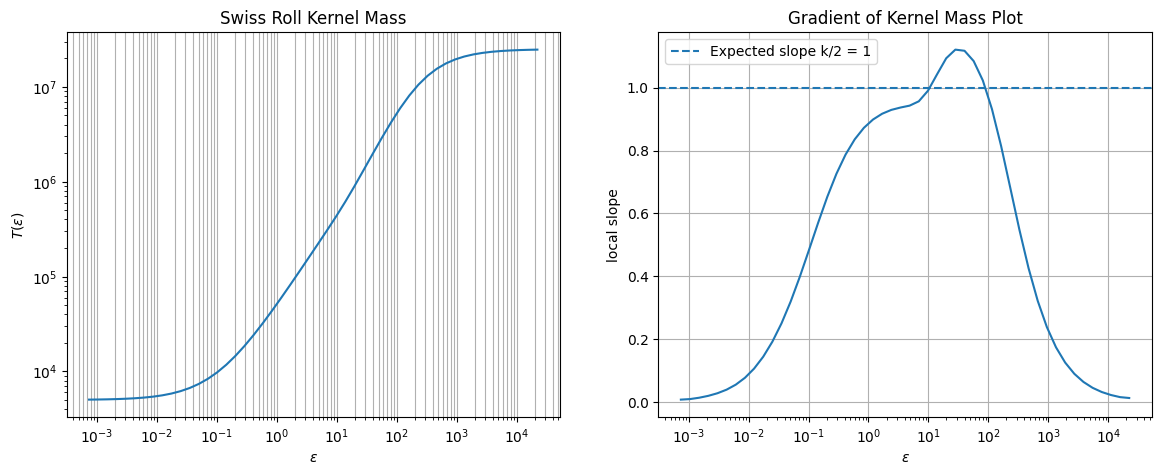

Time taken for kernel mass: 26.35


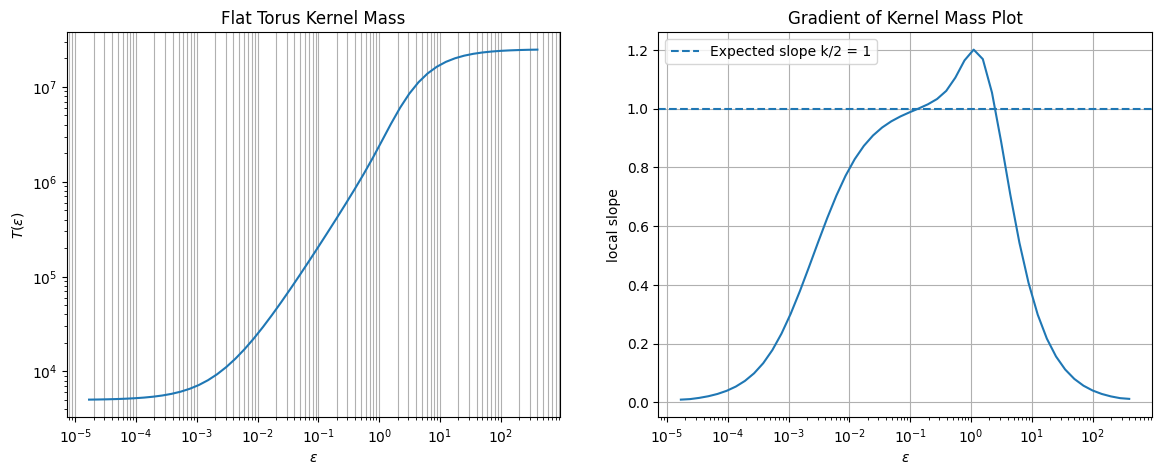

Time taken for kernel mass: 4.11


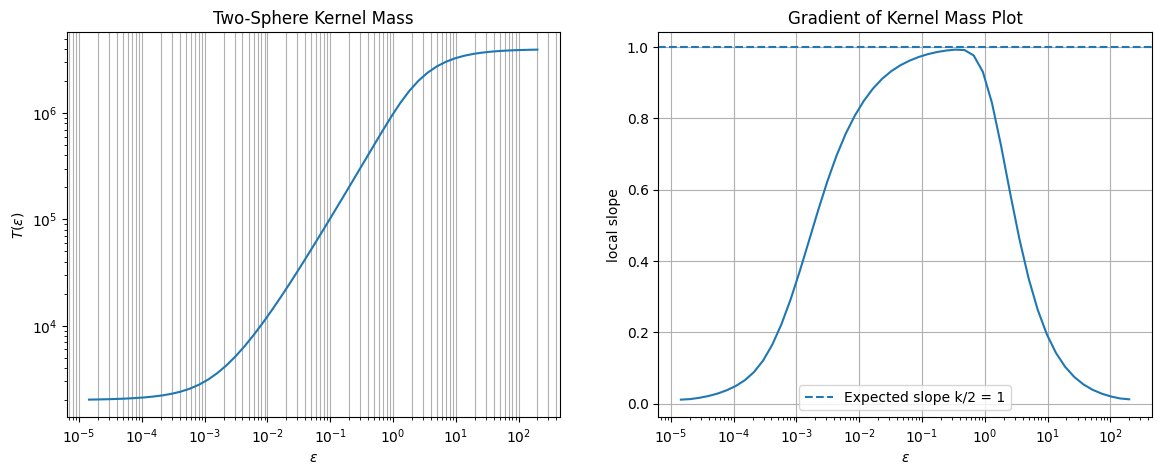

In [64]:
plot_kernel_mass(X_swiss_roll, title="Swiss Roll Kernel Mass")
plot_kernel_mass(X_torus, title="Flat Torus Kernel Mass")
plot_kernel_mass(X_sphere, title="Two-Sphere Kernel Mass")

### Visual analysis

- Swiss roll: $\varepsilon \in [0.2, 100]$
- Flat torus: $\varepsilon \in [0.03, 0.6]$
- Two sphere: $\varepsilon \in [0.05, 0.5]$

### Fitting slopes for each linear regime

In [73]:
def log_polyfit(x, y, deg=1):
    '''
    Returns the gradient and intercept of the linear 
    approximation of (log(x), log(y))
    '''
    log_x = np.log10(x)
    log_y = np.log10(y)

    m, c = np.polyfit(log_x, log_y, deg=deg)

    return m, c

In [67]:

# Linear regions identified visually
eps_sr_reg = [0.2, 100]
eps_ft_reg = [0.03, 0.6]
eps_ts_reg = [0.05, 0.5]


# Swiss roll
# region of epsilon grid for linear behaviour
eps_grid_sr = np.logspace(np.log10(eps_sr_reg[0]), np.log10(eps_sr_reg[1]), 40)
# Computing the kernel mass for this region
d_sr = sp.spatial.distance.pdist(X_swiss_roll)**2
D_sr = sp.spatial.distance.squareform(d_sr)
T_eps_sr, _ = kernel_mass(D_sr, eps_grid_sr)
# Computing the slope of the linear region
m_sr, c_sr = log_polyfit(eps_grid_sr, T_eps_sr)
print(f'Linear regime Gradient for swiss roll: {m_sr:.2f}')


# Flat torus
eps_grid_ft = np.logspace(np.log10(eps_ft_reg[0]), np.log10(eps_ft_reg[1]), 40)
d_ft = sp.spatial.distance.pdist(X_torus)**2
D_ft = sp.spatial.distance.squareform(d_ft)
T_eps_ft, _ = kernel_mass(D_ft, eps_grid_ft)
m_ft, c_ft = log_polyfit(eps_grid_ft, T_eps_ft)
print(f'Linear regime Gradient for flat torus: {m_ft:.2f}')

# Two-sphere
eps_grid_ts = np.logspace(np.log10(eps_ts_reg[0]), np.log10(eps_ts_reg[1]), 40)
d_ts = sp.spatial.distance.pdist(X_sphere)**2
D_ts = sp.spatial.distance.squareform(d_ts)
T_eps_ts, _ = kernel_mass(D_ts, eps_grid_ts)
m_ts, c_ts = log_polyfit(eps_grid_ts, T_eps_ts)
print(f'Linear regime Gradient for two-sphere: {m_ts:.2f}')


Linear regime Gradient for swiss roll: 0.96
Linear regime Gradient for flat torus: 1.00
Linear regime Gradient for two-sphere: 0.98


In [ ]:
def plot_kernel_mass_2(X, title="Kernel Mass Annotated Plot", ax=None, linear_region=None, fit_line=True):
    # Calculate squared distances between xi xj
    d = sp.spatial.distance.pdist(X)**2
    D = sp.spatial.distance.squareform(d)

    ### FIX: Found median of minimal distance of each row
    ### this is used to set the lower end of the grid
    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.inf)

    d_min = np.median(np.min(D_no_diag, axis=1))
    d_med = np.median(d)

    eps_grid = np.logspace(
        np.log10(d_min) - 2,
        np.log10(d_med) + 2,
        50
    )

    T_eps, _ = kernel_mass(D, eps_grid)

    if linear_region is not None:
        eps_lo, eps_hi = linear_region
        mask = (eps_grid >= eps_lo) & (eps_grid <= eps_hi)
        eps_fit = eps_grid[mask]
        T_fit = np.asarray(T_eps)[mask]
        m, c = log_polyfit(eps_fit, T_fit)
    else:
        m, c = log_polyfit(eps_grid, T_eps)
        eps_lo, eps_hi = None, None

    if ax is not None:
        ax.loglog(eps_grid, T_eps, label="kernel mass")
        if linear_region is not None:
            ax.axvspan(eps_lo, eps_hi, color="tab:orange", alpha=0.18, label="linear window")
        if fit_line:
            eps_line = np.linspace(eps_grid.min(), eps_grid.max(), 300)
            T_line = 10 ** (m * np.log10(eps_line) + c)
            ax.loglog(eps_line, T_line, "--", color="tab:red", label=f"fit: m={m:.2f}")
        ax.set_title(title)
        ax.set_xlabel(r"$\varepsilon$")
        ax.set_ylabel(r"$T(\varepsilon)$")
        ax.legend()
    else:
        plt.loglog(eps_grid, T_eps, label="kernel mass")
        if linear_region is not None:
            plt.axvspan(eps_lo, eps_hi, color="tab:orange", alpha=0.18, label="linear window")
        if fit_line:
            eps_line = np.linspace(eps_grid.min(), eps_grid.max(), 300)
            T_line = 10 ** (m * np.log10(eps_line) + c)
            plt.loglog(eps_line, T_line, "--", color="tab:red", label=f"fit: m={m:.2f}")
        plt.title(title)
        plt.xlabel(r"$\varepsilon$")
        plt.ylabel(r"$T(\varepsilon)$")
        plt.legend()
        plt.show()

### Annotated kernel mass plots

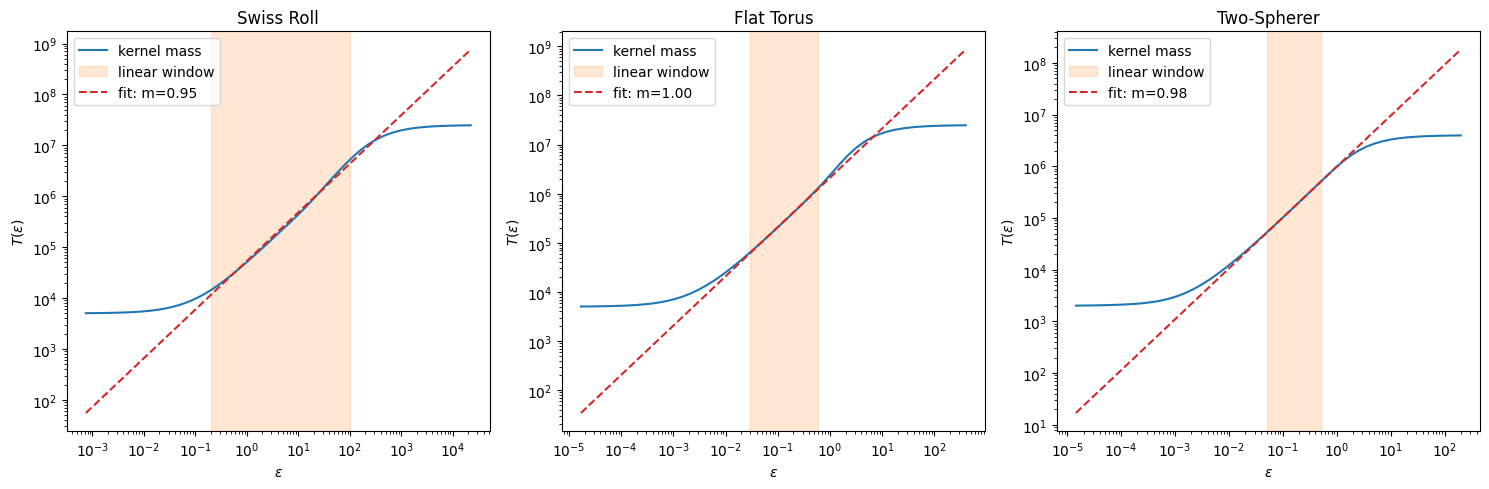

In [74]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figheight(5)
fig.set_figwidth(15)

plot_kernel_mass_2(X_swiss_roll, title="Swiss Roll", ax=ax1, linear_region=eps_sr_reg)
plot_kernel_mass_2(X_torus, title="Flat Torus", ax=ax2, linear_region=eps_ft_reg)
plot_kernel_mass_2(X_sphere, title="Two-Spherer", ax=ax3, linear_region=eps_ts_reg)

fig.tight_layout()

### Selecting bandwidth by $\varepsilon^\star = \sqrt{\varepsilon_\text{min} \varepsilon_\text{max}}$

In [78]:
EPS_SR = np.sqrt(eps_sr_reg[0]*eps_sr_reg[1])
EPS_FT = np.sqrt(eps_ft_reg[0]*eps_ft_reg[1])
EPS_TS = np.sqrt(eps_ts_reg[0]*eps_ts_reg[1])

### Bandwidth results table
| Data Cloud | Linear $\varepsilon$ Grid | Linear Approximation Error | $\varepsilon^*$ |
| :--- | :---: | :---: | :---: |
| Swiss Roll | $[0.2, 100]$ | $5\%$ | $4.5$ |
| Flat Torus | $[0.03, 0.6]$ | $0\%$ | $0.13$ |
| Two Sphere | $[0.05, 0.5]$ | $2\%$ | $0.16$ |

# 1.4. Spectral gap analysis

In [ ]:
def transition_matrix(X, epsilon=None, alpha=1):
    # Distance matrix
    d = sp.spatial.distance.pdist(X)
    D = sp.spatial.distance.squareform(d) ** 2

    # Gaussian affinity matrix
    if epsilon is None:
        epsilon = np.mean(D)
    W = np.exp(-D / epsilon)

    # Normalised affinity matrix
    q = np.sum(W, axis=1)
    W_a = W / np.outer(np.power(q, alpha), np.power(q, alpha))

    # Transition Matrix
    P = W_a / np.sum(W_a, axis=1, keepdims=True)

    # Compute eigenvalues of S which is related to P and symmetric
    d_alpha = np.sum(W_a, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d_alpha))
    S = D_inv_sqrt @ W_a @ D_inv_sqrt

    return P, S


X_sr = X_swiss_roll
X_ft = X_torus
X_ts = X_sphere

P_sr, S_sr = transition_matrix(X_sr, epsilon=EPS_SR)
P_ft, S_ft = transition_matrix(X_ft, epsilon=EPS_FT)
P_ts, S_ts = transition_matrix(X_ts, epsilon=EPS_TS)


In [83]:
manifold_matrices = {
    "Swiss roll": [P_sr, S_sr],
    "Flat torus": [P_ft, S_ft],
    "Two-sphere": [P_ts, S_ts],
}

eigenvalues = {}
eigenvectors = {}

for name, matrix in manifold_matrices.items():
    S = matrix[1]
    n = S.shape[0]
    n = S.shape[0]
    if n <= 5000:
        w, v = np.linalg.eigh(S)
    else:
        w, v = sp.sparse.linalg.eigsh(S)

    idx = np.argsort(w.real)[::-1]
    w = w[idx]
    v = v[:, idx]

    eigenvalues[name] = w[1:]
    eigenvectors[name] = v[:, 1:]


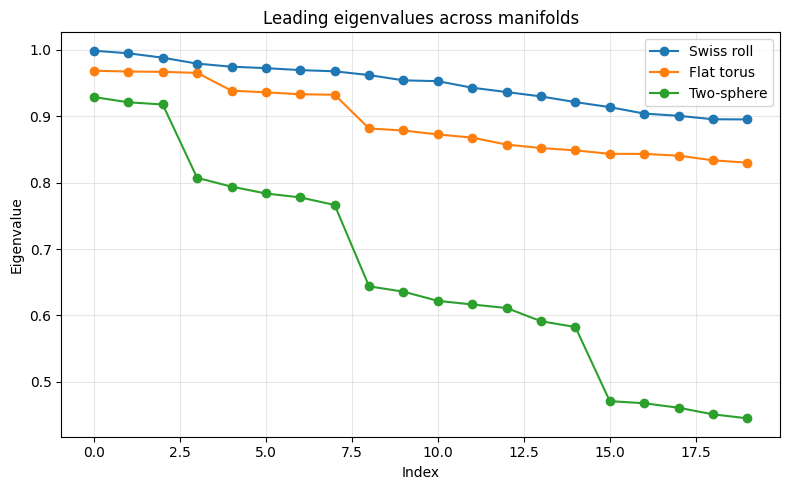

In [85]:
plt.figure(figsize=(8, 5))
for name, w in eigenvalues.items():
    plt.plot(w[:20], marker='o', label=name)
plt.title('Leading eigenvalues across manifolds')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

- For the two-sphere, we can see that for $\mathcal{l}=1$ we have 3 ($2\mathcal{l}+1$) eigenvalues of very similar values, for $\mathcal{l}=2$ we have 5, etc. This checks out with what you said.

- For the flat torus the eigenvalues seem to be grouped into groups of 4

- For the Swiss roll the gap immediately after the second eigenvalue is not the biggest, but the the sum of the two gaps following the second eigenvalue is the largest of any sum of two gaps. The Swiss roll is calling problems still.

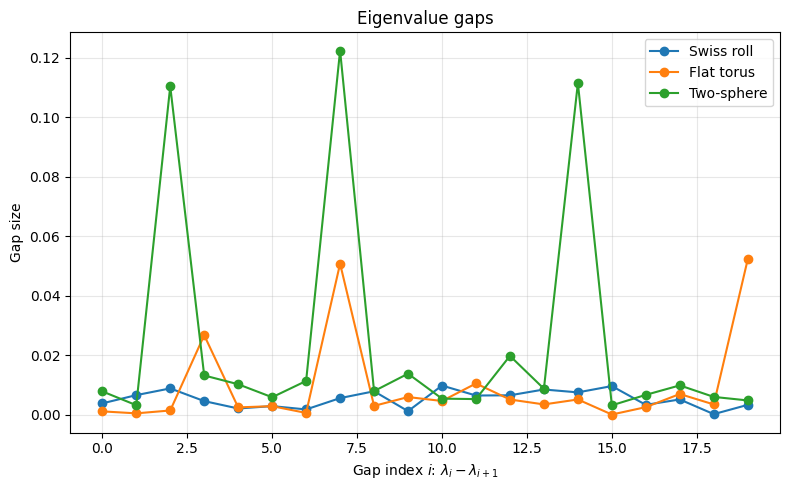

In [89]:
plt.figure(figsize=(8, 5))

for name, w in eigenvalues.items():
    gaps = w[:-1] - w[1:]
    gaps = gaps[:20]
    plt.plot(np.arange(len(gaps)), gaps, marker='o', label=name)

plt.title("Eigenvalue gaps")
plt.xlabel(r"Gap index $i$: $\lambda_i - \lambda_{i+1}$")
plt.ylabel("Gap size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1.5. Recovery of geodesic distance

In [ ]:
np.random.seed(0)

X_ft, theta_ft, phi_ft = flat_torus(n=5000, angles=True)
X_ts = two_sphere(n=5000)

Psi_ft = embedding_real(X_ft, epsilon=EPS_FT, k=5)
Psi_ts = embedding_real(X_ts, epsilon=EPS_TS, k=5)


In [27]:
a = np.random.choice(5000, size=500)
b = np.random.choice(5000, size=500)

pairs = np.stack((a, b), axis=1)

In [28]:
def diffusion_distance(Psi, pairs):
    '''
    Get the distance between each pair of embedded points
    following the equation in pdf
    '''
    diffs = Psi[pairs[:, 0]] - Psi[pairs[:, 1]]
    return np.linalg.norm(diffs, axis=1)
    
def analytic_dist_sphere(X, pairs):
    '''
    Get the distance between each point on the two-sphere
    using analytic solution
    '''
    dots = np.sum(X[pairs[:, 0]] * X[pairs[:, 1]], axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    return np.arccos(dots)

def analytic_dist_torus(theta, phi, pairs):
    '''
    Get the distance between each point on the flat torus
    using the geodesic equation given in the notes
    
    '''
    t1 = theta[pairs[:, 0]]
    t2 = theta[pairs[:, 1]]

    p1 = phi[pairs[:, 0]]
    p2 = phi[pairs[:, 1]]

    dt = np.abs(t1 - t2)
    dp = np.abs(p1 - p2)

    dt = np.minimum(dt, 2*np.pi - dt)
    dp = np.minimum(dp, 2*np.pi - dp)

    return np.sqrt(dt**2 + dp**2)

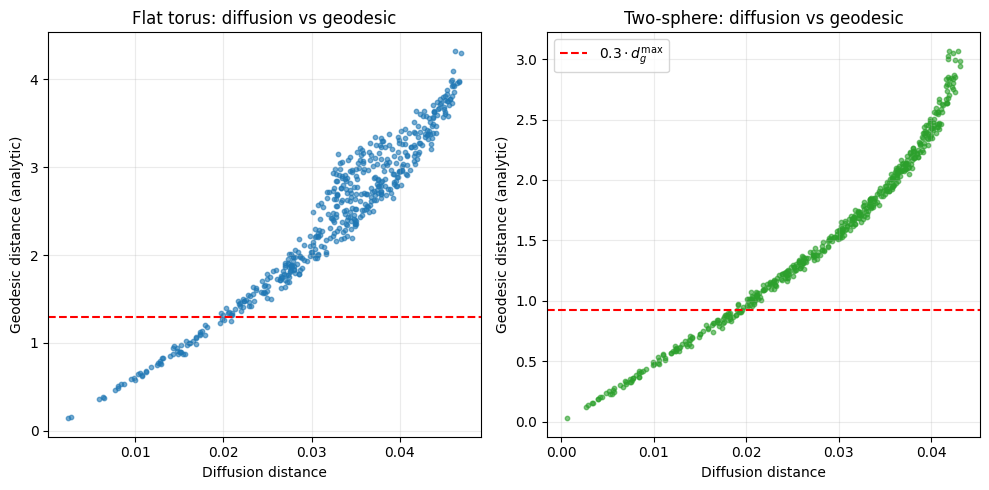

In [29]:
# Running the embedding function for k=5 means
# that I can investigate different values of k
# without rerunning embedding
k_ft = 4
k_ts = 3

Psi_ft_k = Psi_ft[:, :k_ft]
Psi_ts_k = Psi_ts[:, :k_ts]

# Embedding distances
D_ft = diffusion_distance(Psi_ft_k, pairs)
D_ts = diffusion_distance(Psi_ts_k, pairs)

# Analytic geodesic distances
d_ft = analytic_dist_torus(theta_ft, phi_ft, pairs)
d_ts = analytic_dist_sphere(X_ts, pairs)

# Maximum goedisic distance
d_ft_max = max(d_ft)
d_ts_max = max(d_ts)

# Get rid of all points which are too far apart
mask_ft = d_ft < 0.3*d_ft_max
mask_ts = d_ts < 0.3*d_ts_max

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(10)

# Flat torus: scatter diffusion vs analytic geodesic (subset)
x1 = D_ft.flatten() # D_ft[mask_ft].flatten()
y1 = d_ft.flatten() # d_ft[mask_ft].flatten()
ax1.scatter(x1, y1, s=10, alpha=0.6, color='tab:blue')
ax1.axhline(0.3*d_ft_max, ls="--", color="r", label=r"$0.3 \cdot d_g^{\text{max}}$")
ax1.set_title('Flat torus: diffusion vs geodesic')
ax1.set_xlabel('Diffusion distance')
ax1.set_ylabel('Geodesic distance (analytic)')
ax1.grid(alpha=0.25)


# Two-sphere: scatter diffusion vs analytic geodesic (subset)
x2 = D_ts.flatten() # D_ts[mask_ts].flatten()
y2 = d_ts.flatten() # d_ts[mask_ts].flatten()
ax2.scatter(x2, y2, s=10, alpha=0.6, color='tab:green')
ax2.axhline(0.3*d_ts_max, ls="--", color="r", label=r"$0.3 \cdot d_g^{\text{max}}$")
ax2.set_title('Two-sphere: diffusion vs geodesic')
ax2.set_xlabel('Diffusion distance')
ax2.set_ylabel('Geodesic distance (analytic)')
ax2.grid(alpha=0.25)

fig.tight_layout()
plt.legend()
plt.show()


In [30]:
import pandas as pd

rows = []

def analyze_embedding(name, Psi, geo_func, max_k=None):
    ncols = Psi.shape[1]
    maxk = ncols if max_k is None else min(ncols, max_k)
    for k in range(1, maxk + 1):
        D_emb = diffusion_distance(Psi[:, :k], pairs)
        d_geo = geo_func()

        d_max = max(d_geo)
        mask = d_geo < 0.3 * d_max

        D_emb = np.asarray(D_emb)[mask].flatten()
        d_geo = np.asarray(d_geo)[mask].flatten()

        mask = ~np.isnan(D_emb) & ~np.isnan(d_geo)
        if np.sum(mask) < 2:
            slope = np.nan
            r2 = np.nan
        else:
            res = sp.stats.linregress(D_emb[mask], d_geo[mask])
            slope = res.slope
            r2 = res.rvalue ** 2

        rows.append({'manifold': name, 'k': k, 'slope': slope, 'R2': r2, 'n_pairs': int(np.sum(mask))})


if 'Psi_ft' in globals():
    analyze_embedding('Flat torus', Psi_ft, lambda: analytic_dist_torus(theta_ft, phi_ft, pairs))
if 'Psi_ts' in globals():
    analyze_embedding('Two-sphere', Psi_ts, lambda: analytic_dist_sphere(X_ts, pairs))

df = pd.DataFrame(rows)
display(df)


,manifold,k,slope,R2,n_pairs
0,Flat torus,1,25.896864,0.217389,59
1,Flat torus,2,34.835047,0.377345,59
2,Flat torus,3,49.957604,0.628203,59
3,Flat torus,4,63.642876,0.983538,59
4,Flat torus,5,44.763356,0.810813,59
5,Two-sphere,1,24.910956,0.212965,106
6,Two-sphere,2,44.267101,0.694976,106
7,Two-sphere,3,48.505440,0.991793,106
8,Two-sphere,4,33.944433,0.798844,106
9,Two-sphere,5,29.375243,0.779427,106


$D_t(x_i, x_j)$ measures the difference between the heat distributions at time $t$ on the manifold which start from points $x_i$ and $x_j$. The geodesic distance $d_g(x_i, x_j)$ represents the shortest possible path between points $x_i$ and $x_j$. As the geodesic distance between the points increases, the value $D$ starts to be dominated by the leading eigendirection because $\lambda_l < 1$ for $l \ge 1$, so for larger distances the embedding approximation becomes smoother and therefore looses information given by the different eigenvectors. This is more obvious at higher distances.